## Analyze the shopping trend dataset by answering the questions below.
> **IMPORTANT** write your insights after each question

# Read the data

In [43]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "shopping_trends_updated.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "iamsouravbanerjee/customer-shopping-trends-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df.head()

/tmp/ipython-input-1162196871.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'customer-shopping-trends-dataset' dataset.


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


### Question 1
What is the distribution of `Purchase Amount (USD)` for different `Subscription Status` values?
- Plot using both **Seaborn’s `boxplot` and Matplotlib’s histogram**.
- Are there any outliers?

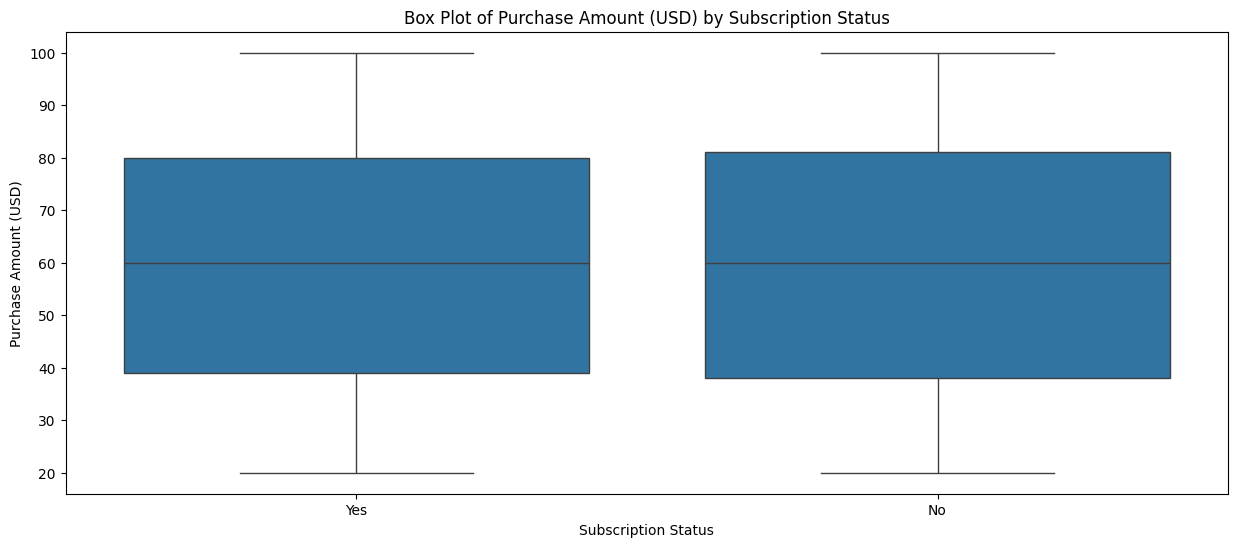

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.figure(figsize=(15, 6))
sns.boxplot(x='Subscription Status', y='Purchase Amount (USD)', data=df)
plt.title('Box Plot of Purchase Amount (USD) by Subscription Status')
plt.xlabel('Subscription Status')
plt.ylabel('Purchase Amount (USD)')
plt.show()
# There are no outliars

### Question 2
Compare the frequency of each `Payment Method` across the dataset **from highest to lowest** .
- Use both **Seaborn's `countplot`** and **Matplotlib's bar plot**.

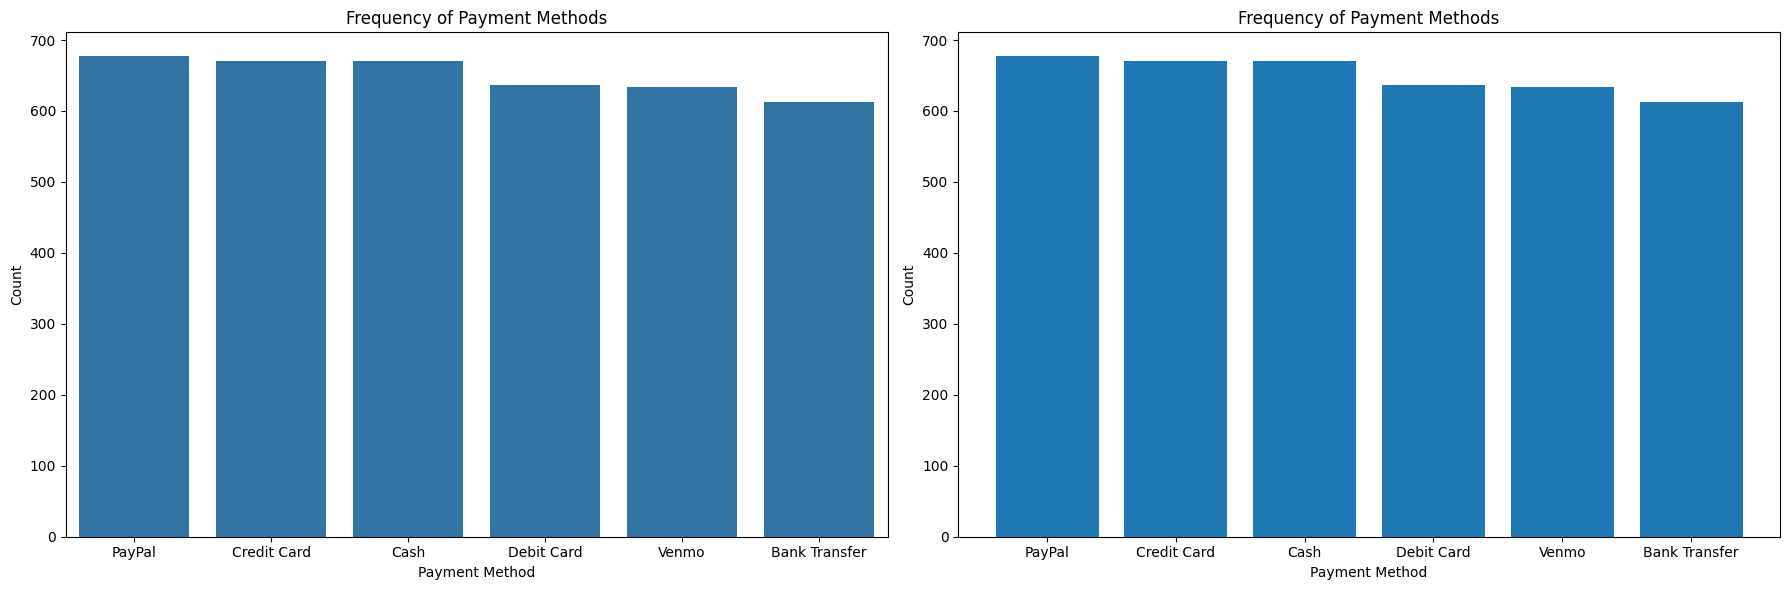

In [45]:
payment_method_counts = df['Payment Method'].value_counts()
payment_method_order = payment_method_counts.index
plt.figure(figsize=(18, 6))

# Seaborn's countplot
plt.subplot(1, 2, 1)
sns.countplot(x='Payment Method', data=df, order=payment_method_order)
plt.title('Frequency of Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Count')

# Matplotlib's bar plot
plt.subplot(1, 2, 2)
plt.bar(payment_method_order, payment_method_counts.values)
plt.title('Frequency of Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

### Question 3
Show the number of purchases made by each `Gender` in each `Season`.
- Create a **grouped bar chart/ Pie chart using Matplotlib**.
- Also plot a **stacked countplot using Seaborn**.

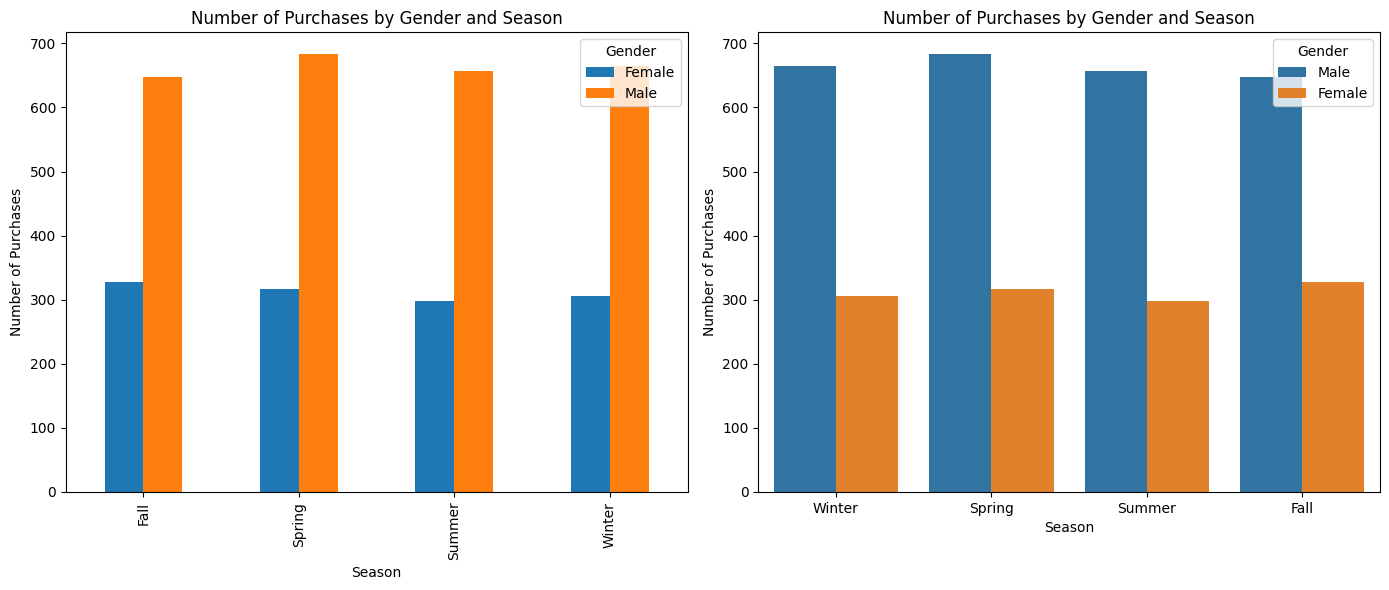

In [46]:
purchases_by_gender_season = df.groupby(['Season', 'Gender']).size().unstack(fill_value=0)
plt.figure(figsize=(14, 6))

# Matplotlib Grouped Bar Chart
plt.subplot(1, 2, 1)
purchases_by_gender_season.plot(kind='bar', ax=plt.gca())
plt.title('Number of Purchases by Gender and Season')
plt.xlabel('Season')
plt.ylabel('Number of Purchases')
plt.legend(title='Gender')

# Seaborn Stacked Countplot
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Season', hue='Gender')
plt.title('Number of Purchases by Gender and Season')
plt.xlabel('Season')
plt.ylabel('Number of Purchases')
plt.legend(title='Gender')

plt.tight_layout()
plt.show()

### Question 4
Create a heatmap showing the correlation between all numeric columns.
- Use `sns.heatmap`.
- Interpret the relationship between `Previous Purchases`, `Purchase Amount`, and `Review Rating`.

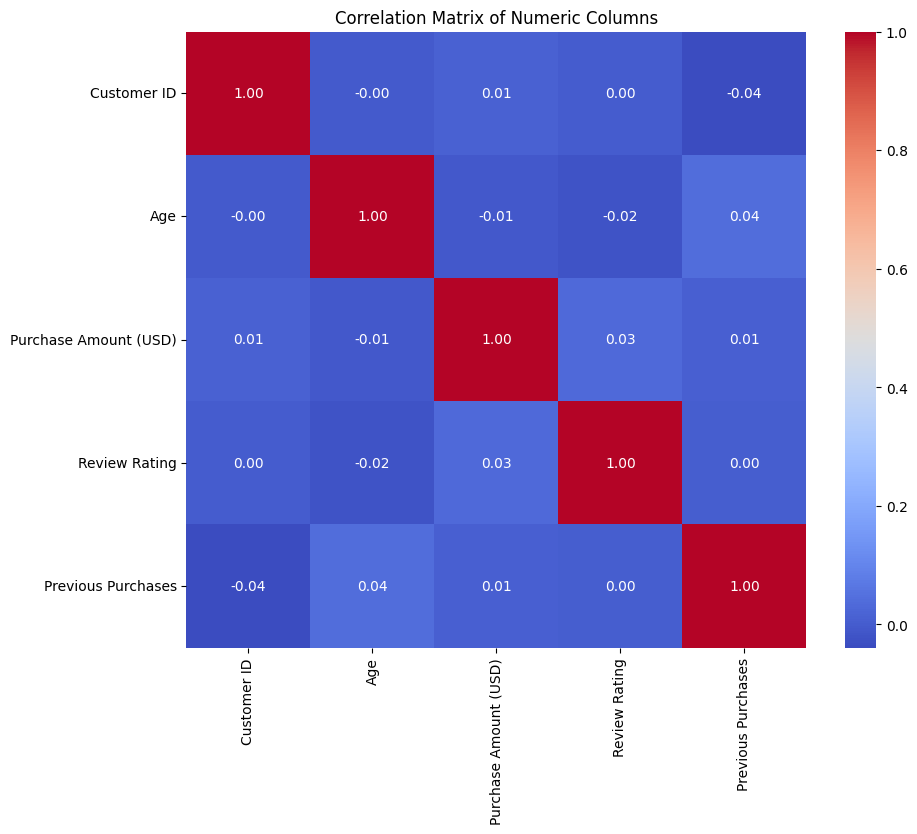

In [47]:
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Columns')
plt.show()

# Interpretation of relationships:
# Previous Purchases, Purchase Amount --> NO COLLERATION
# Purchase Amount,Review Rating  --> NO COLLERATION
# Previous Purchases, Review Rating --> NO COLLERATION

### Question 5
Create a scatter plot of `Age` vs `Purchase Amount (USD)`, color-coded by `Gender`.
- Use **Matplotlib and Seaborn side-by-side**.
- Add a trend line in Seaborn using `regplot`.

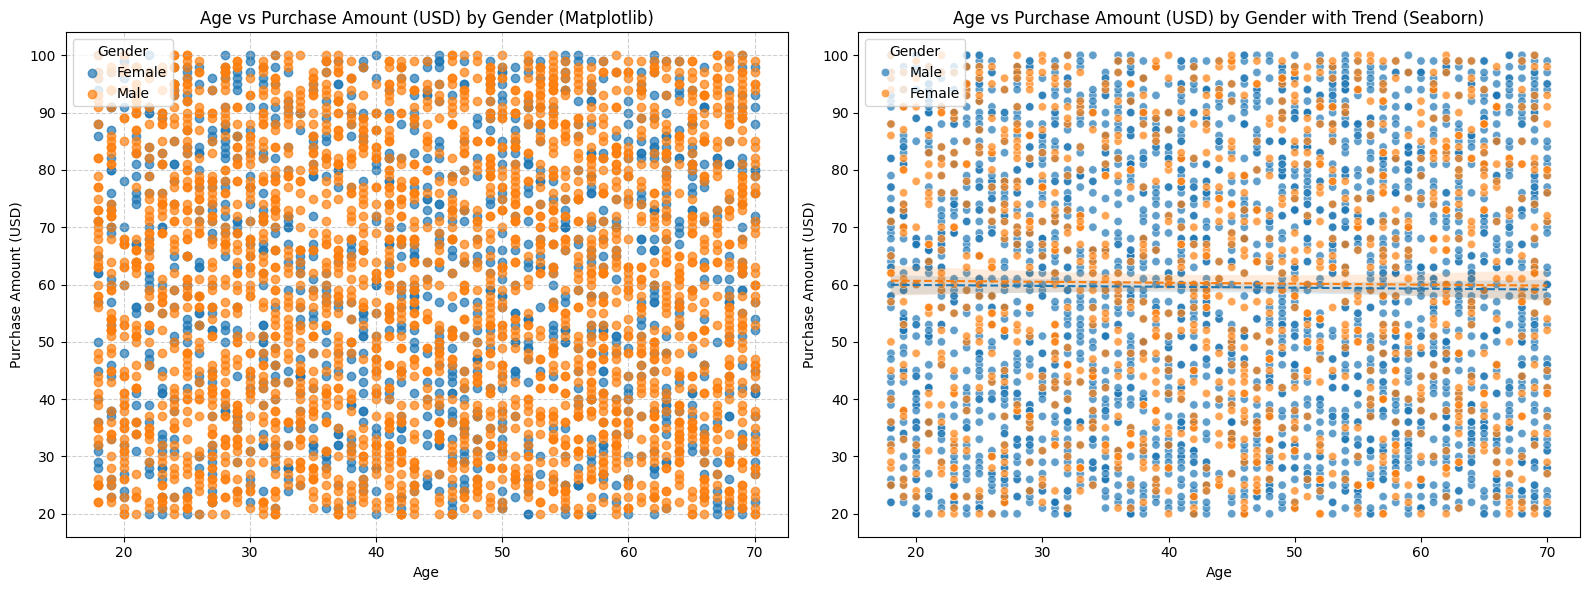

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(16, 6))

# Matplotlib Scatter Plot
plt.subplot(1, 2, 1)
for gender, group in df.groupby('Gender'):
    plt.scatter(group['Age'], group['Purchase Amount (USD)'], label=gender, alpha=0.7)
plt.title('Age vs Purchase Amount (USD) by Gender (Matplotlib)')
plt.xlabel('Age')
plt.ylabel('Purchase Amount (USD)')
plt.legend(title='Gender')
plt.grid(True, linestyle='--', alpha=0.6)


ax2 = plt.subplot(1, 2, 2)
sns.scatterplot(x='Age', y='Purchase Amount (USD)', hue='Gender', data=df, ax=ax2, alpha=0.7)

genders = df['Gender'].unique()
default_palette = sns.color_palette(n_colors=len(genders))
gender_color_map = dict(zip(genders, default_palette))

for gender in genders:
    sns.regplot(x='Age', y='Purchase Amount (USD)', data=df[df['Gender'] == gender],
                scatter=False, ax=ax2, color=gender_color_map[gender], line_kws={'linestyle': '--', 'linewidth': 1.5})

plt.title('Age vs Purchase Amount (USD) by Gender with Trend (Seaborn)')
plt.xlabel('Age')
plt.ylabel('Purchase Amount (USD)')

plt.tight_layout()
plt.show()

### Question 6
How does the average review rating differ across different item `Categories` and `Sizes`?
- Use **Seaborn’s heatmap or pivot heatmap** to visualize.
- Use Pandas pivot table to prepare the data.

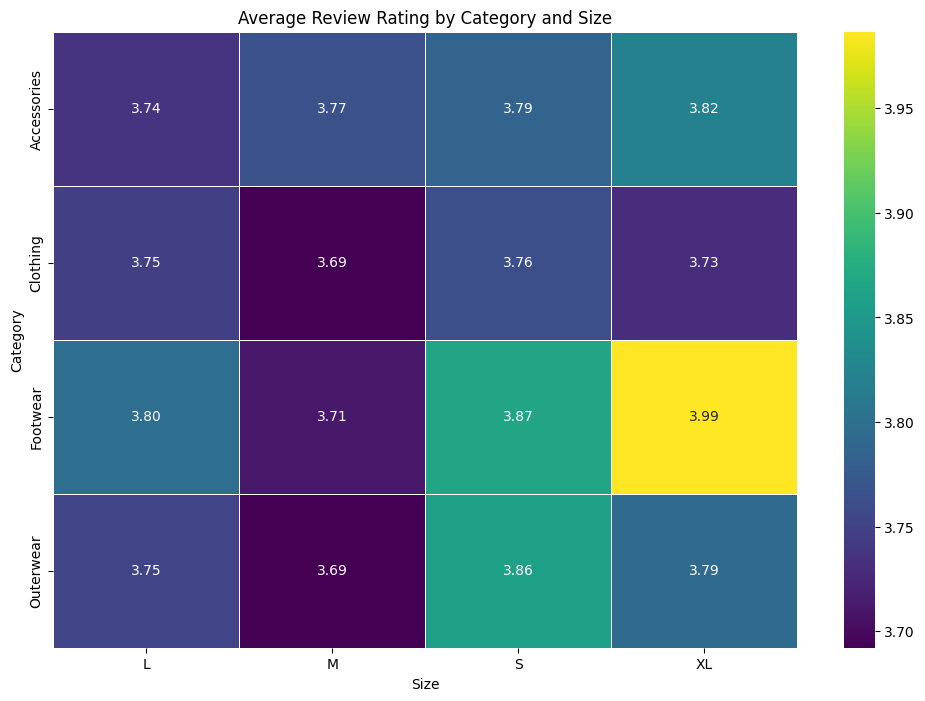

In [49]:
pivot_table = df.pivot_table(values='Review Rating', index='Category', columns='Size', aggfunc='mean')
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, cmap='viridis', fmt='.2f', linewidths=.5)
plt.title('Average Review Rating by Category and Size')
plt.xlabel('Size')
plt.ylabel('Category')
plt.show()

### Question 7
Which combinations of `Season` and `Shipping Type` lead to the highest average `Purchase Amount (USD)`?
- Show this as a **grouped bar chart** and as a **heatmap**.

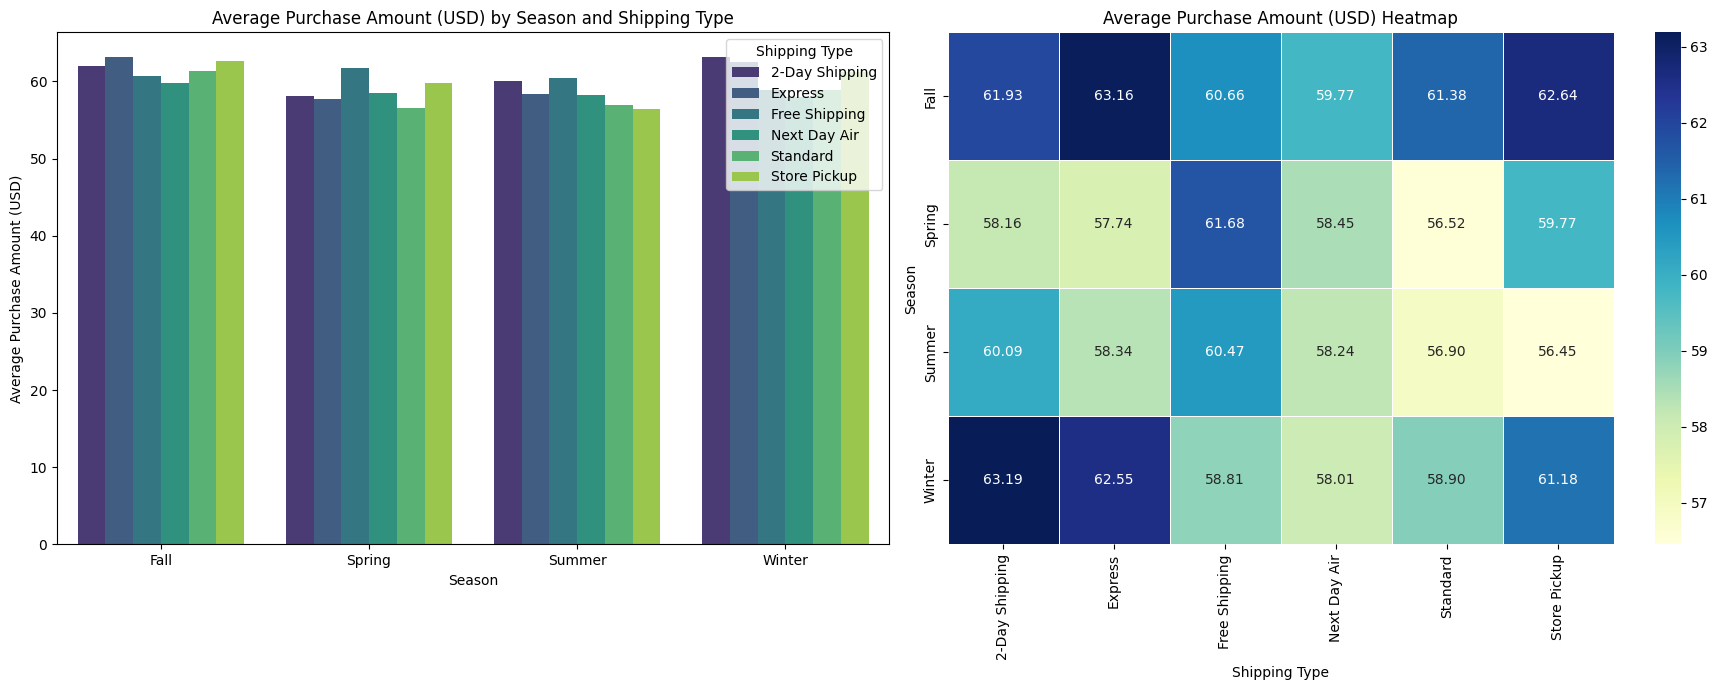

In [50]:
season_shipping_avg_purchase = df.groupby(['Season', 'Shipping Type'])['Purchase Amount (USD)'].mean().reset_index()
sorted_avg_purchase = season_shipping_avg_purchase.sort_values(by='Purchase Amount (USD)', ascending=False)
plt.figure(figsize=(18, 7))

# Grouped Bar Chart
plt.subplot(1, 2, 1)
sns.barplot(x='Season', y='Purchase Amount (USD)', hue='Shipping Type', data=season_shipping_avg_purchase, palette='viridis')
plt.title('Average Purchase Amount (USD) by Season and Shipping Type')
plt.xlabel('Season')
plt.ylabel('Average Purchase Amount (USD)')
plt.legend(title='Shipping Type')

# Heatmap
pivot_table_avg_purchase = season_shipping_avg_purchase.pivot_table(index='Season', columns='Shipping Type', values='Purchase Amount (USD)')

plt.subplot(1, 2, 2)
sns.heatmap(pivot_table_avg_purchase, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=.5)
plt.title('Average Purchase Amount (USD) Heatmap')
plt.xlabel('Shipping Type')
plt.ylabel('Season')

plt.tight_layout()
plt.show()

### Question 8
Plot a violin plot of `Review Rating` by `Gender` for each `Subscription Status`.
- Use `sns.violinplot` with `hue`.

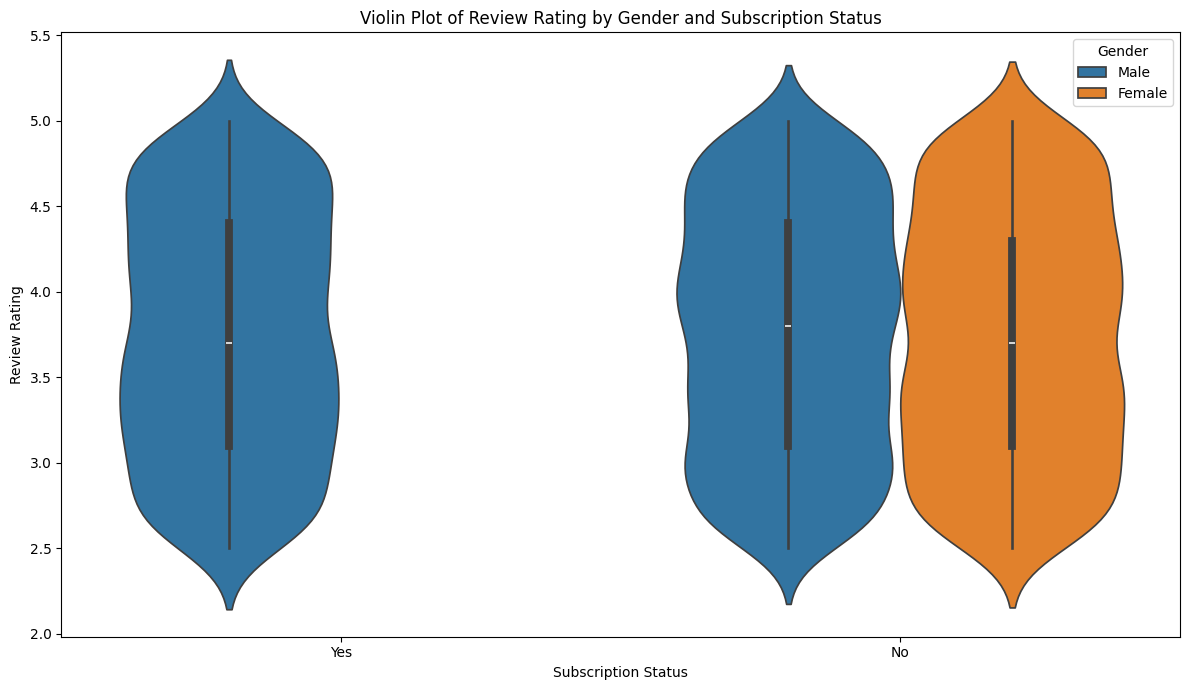

In [51]:
plt.figure(figsize=(12, 7))
sns.violinplot(x='Subscription Status', y='Review Rating', hue='Gender', data=df)
plt.title('Violin Plot of Review Rating by Gender and Subscription Status')
plt.xlabel('Subscription Status')
plt.ylabel('Review Rating')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

### Question 9
What are the top 5 most purchased `Item Purchased` by total `Purchase Amount`?
- Use Pandas aggregation, plot with **Matplotlib pie and bar** charts.

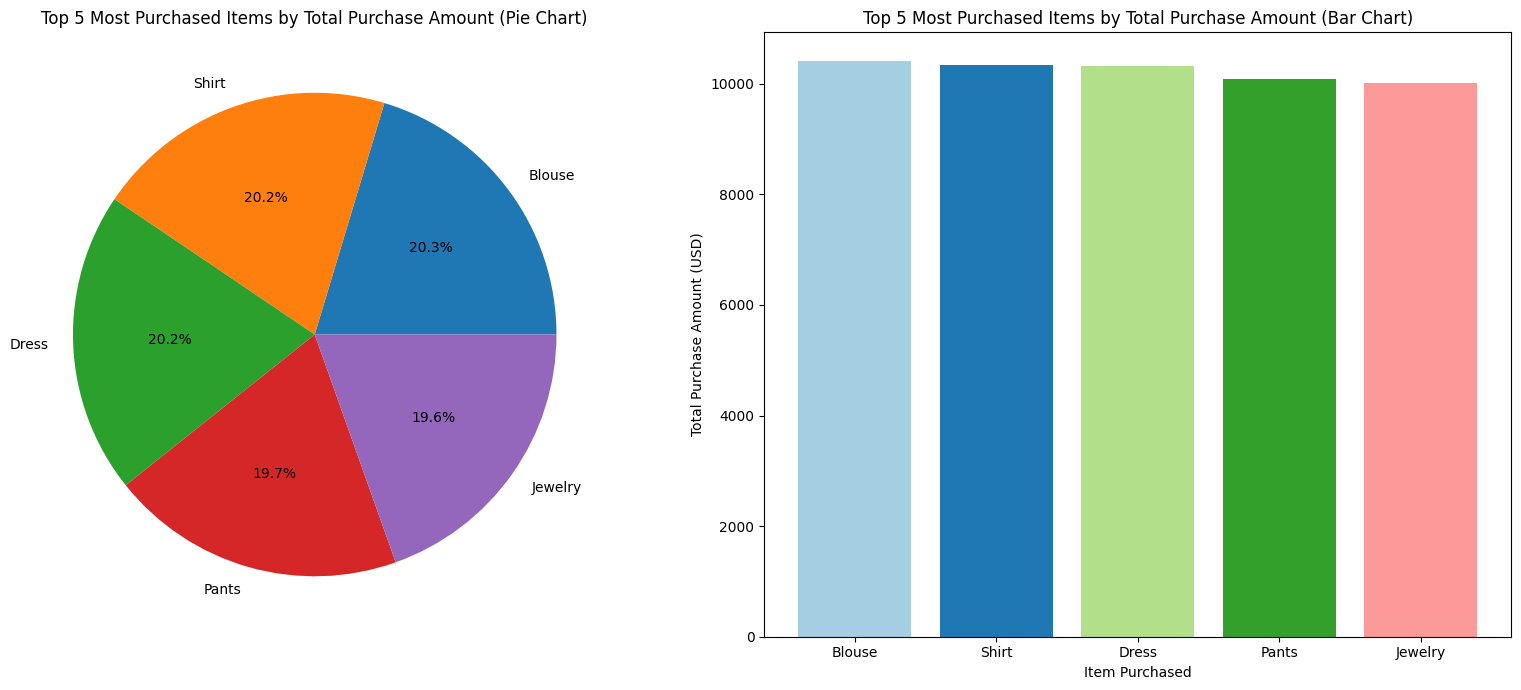

In [52]:
total_purchase_by_item = df.groupby('Item Purchased')['Purchase Amount (USD)'].sum().reset_index()
top_5_items = total_purchase_by_item.sort_values(by='Purchase Amount (USD)', ascending=False).head(5)
plt.figure(figsize=(16, 7))

# Matplotlib Pie Chart
plt.subplot(1, 2, 1)
plt.pie(top_5_items['Purchase Amount (USD)'], labels=top_5_items['Item Purchased'], autopct='%1.1f%%')
plt.title('Top 5 Most Purchased Items by Total Purchase Amount (Pie Chart)')

# Matplotlib Bar Chart
plt.subplot(1, 2, 2)
plt.bar(top_5_items['Item Purchased'], top_5_items['Purchase Amount (USD)'], color=plt.cm.Paired.colors)
plt.title('Top 5 Most Purchased Items by Total Purchase Amount (Bar Chart)')
plt.xlabel('Item Purchased')
plt.ylabel('Total Purchase Amount (USD)')

plt.tight_layout()
plt.show()

### Question 10
Which `Location` has the highest average `Purchase Amount`, and how does it relate to `Previous Purchases` (plot only top 5 purchase amount location)?
- Use a **Seaborn scatterplot** with size/marker variation.

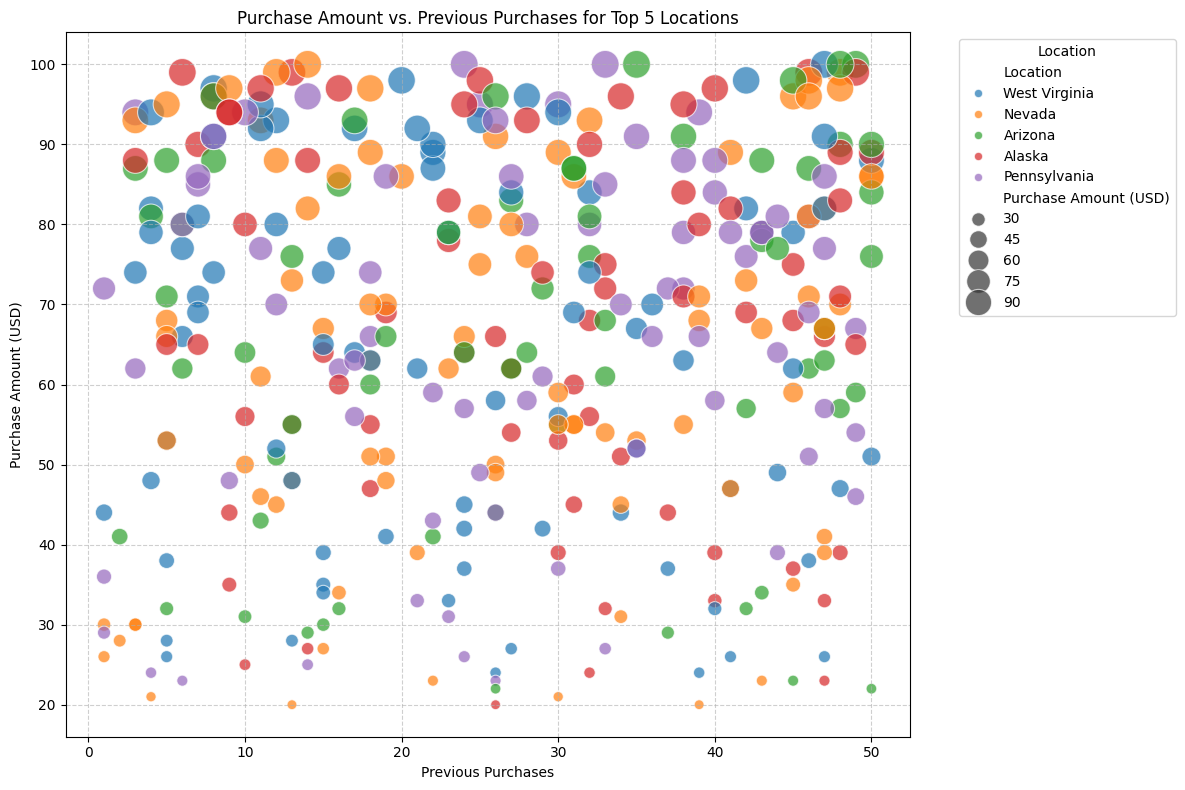

In [53]:
avg_purchase_by_location = df.groupby('Location')['Purchase Amount (USD)'].mean().reset_index()
avg_purchase_by_location = avg_purchase_by_location.sort_values(by='Purchase Amount (USD)', ascending=False)
top_5_locations = avg_purchase_by_location.head(5)['Location'].tolist()
df_top_5_locations = df[df['Location'].isin(top_5_locations)]

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_top_5_locations,
    x='Previous Purchases',
    y='Purchase Amount (USD)',
    hue='Location',
    size='Purchase Amount (USD)',
    sizes=(50, 400),
    alpha=0.7)
plt.title('Purchase Amount vs. Previous Purchases for Top 5 Locations')
plt.xlabel('Previous Purchases')
plt.ylabel('Purchase Amount (USD)')
plt.legend(title='Location', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Question 11
Using a crosstab, find how `Gender` and `Size` interact.
- Plot using `sns.heatmap`.

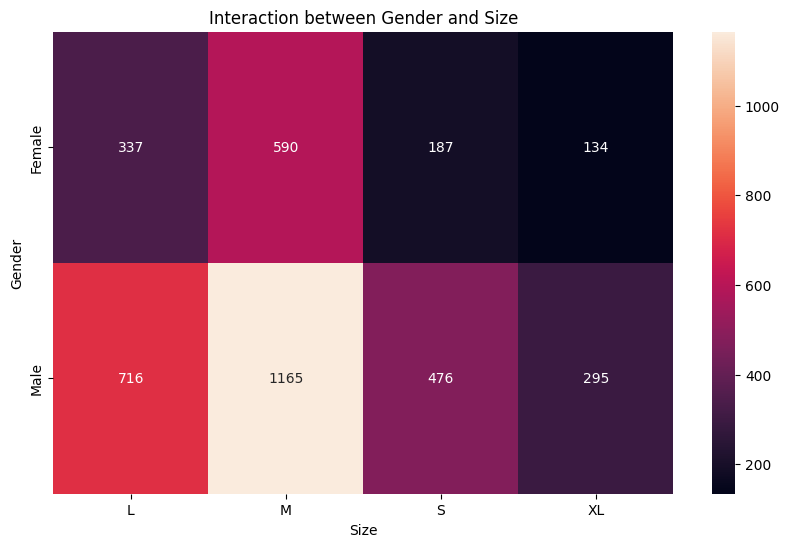

In [54]:
gender_size_crosstab = pd.crosstab(df['Gender'], df['Size'])
plt.figure(figsize=(10, 6))
sns.heatmap(gender_size_crosstab, annot=True, fmt='d')
plt.title('Interaction between Gender and Size')
plt.xlabel('Size')
plt.ylabel('Gender')
plt.show()

### Question 12
How does the frequency of purchases column influence the use of promo codes?
- Create a **stacked bar chart** using Matplotlib and compare with a **Seaborn countplot**.

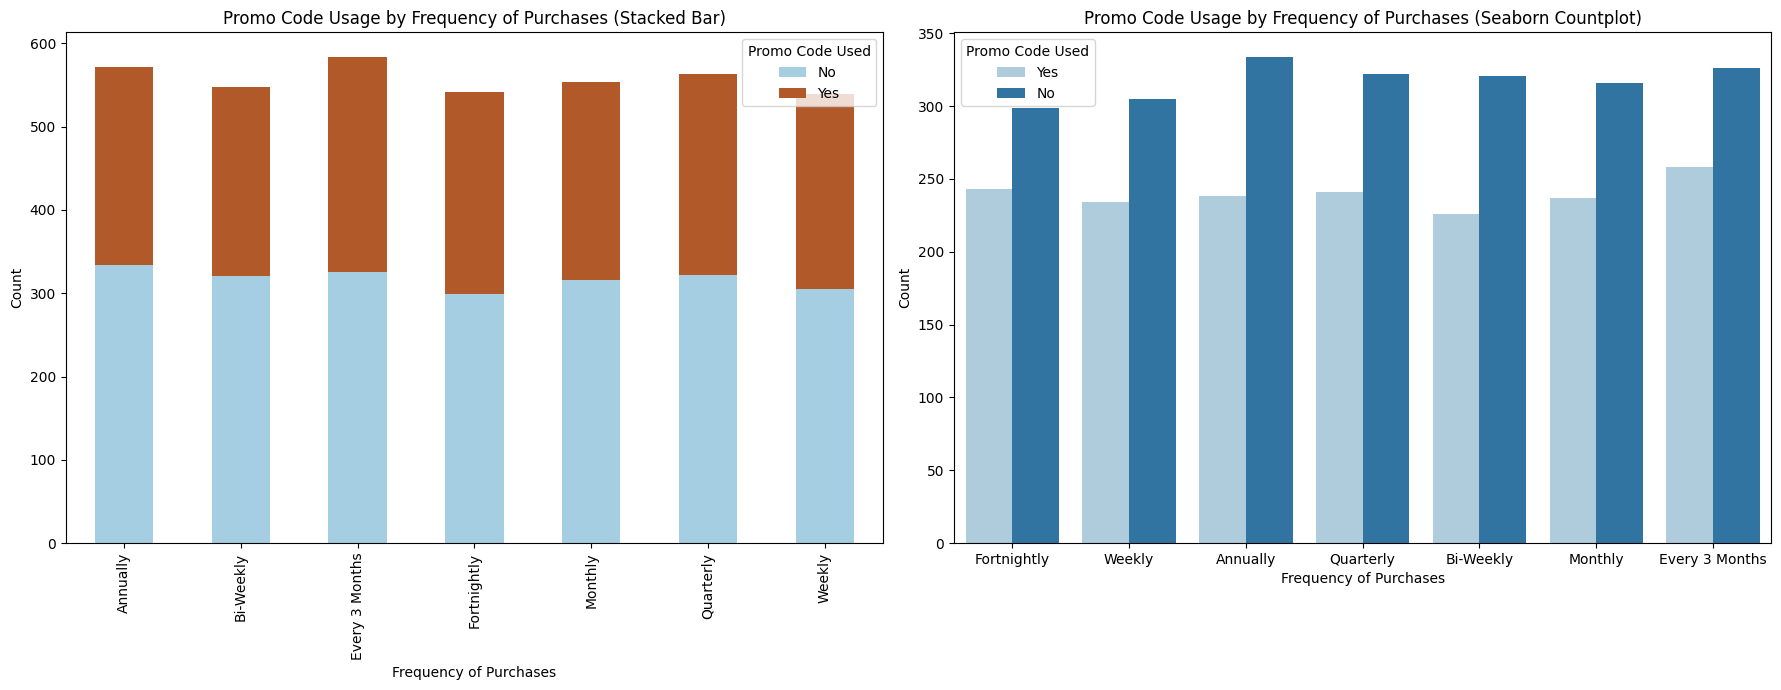

In [55]:
promo_code_frequency = df.groupby(['Frequency of Purchases', 'Promo Code Used']).size().unstack(fill_value=0)
plt.figure(figsize=(18, 7))

# Matplotlib Stacked Bar Chart
plt.subplot(1, 2, 1)
promo_code_frequency.plot(kind='bar', stacked=True, ax=plt.gca(), cmap='Paired')
plt.title('Promo Code Usage by Frequency of Purchases (Stacked Bar)')
plt.xlabel('Frequency of Purchases')
plt.ylabel('Count')
plt.legend(title='Promo Code Used')

# Seaborn Countplot
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Frequency of Purchases', hue='Promo Code Used', palette='Paired')
plt.title('Promo Code Usage by Frequency of Purchases (Seaborn Countplot)')
plt.xlabel('Frequency of Purchases')
plt.ylabel('Count')
plt.legend(title='Promo Code Used')

plt.tight_layout()
plt.show()

### Question 13
Using a pairplot, show pairwise relationships between numeric columns segmented by `Gender`.
- Use `sns.pairplot` with `hue="Gender"`.

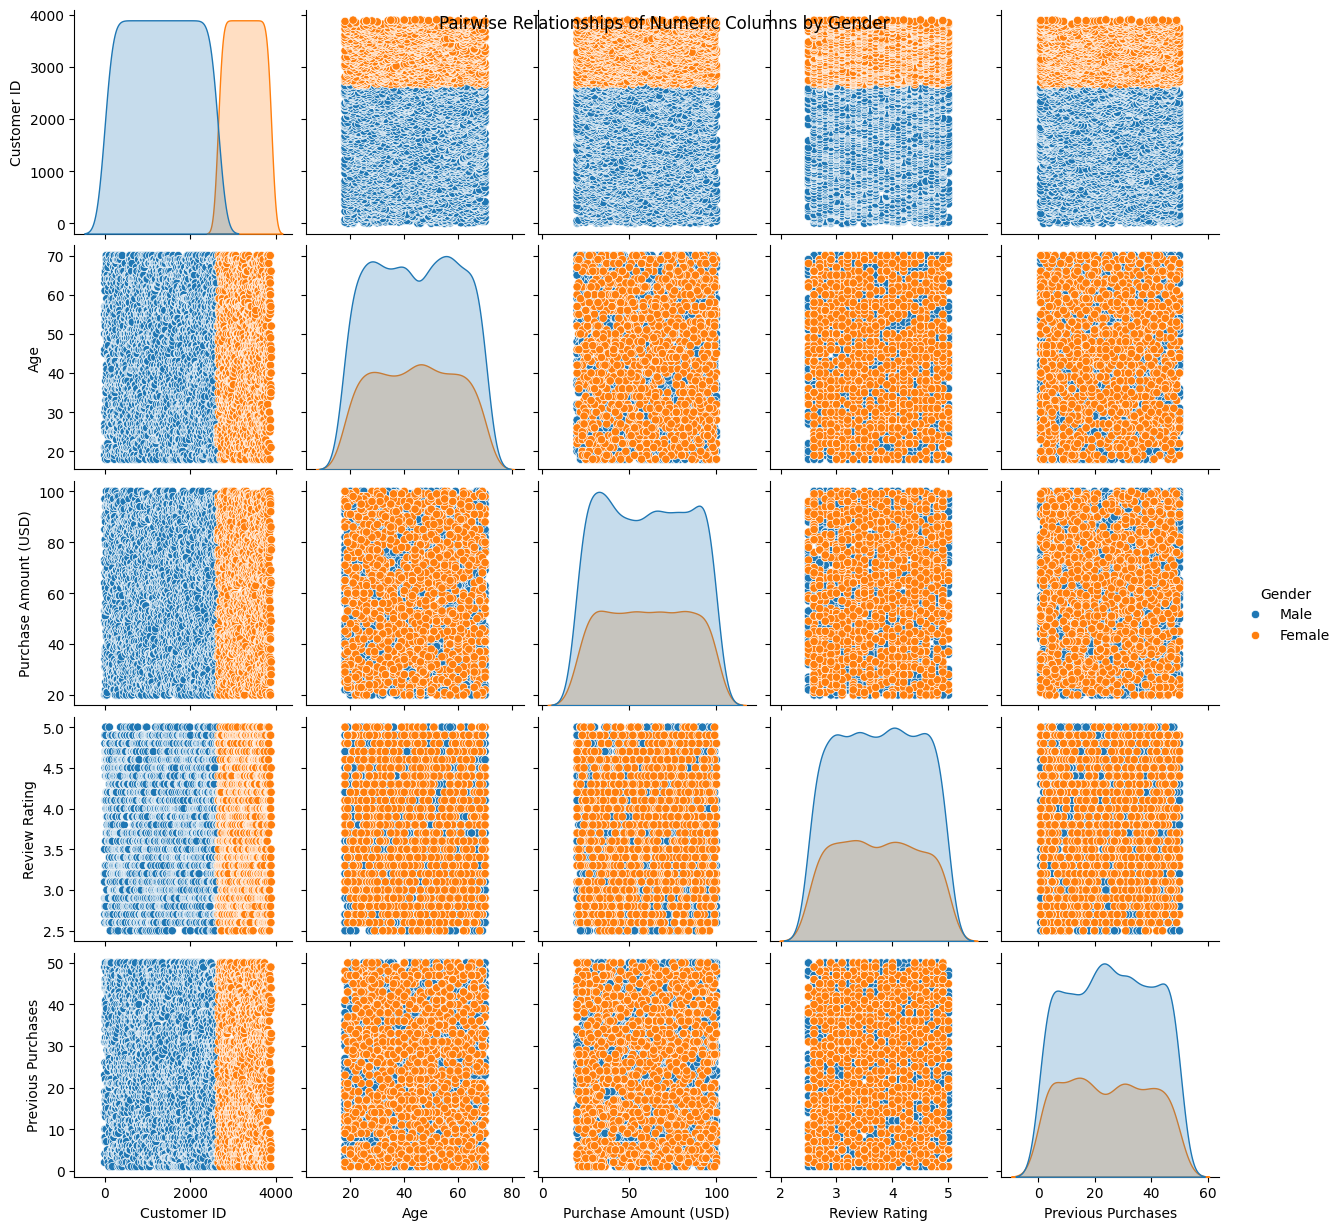

In [56]:
numeric_df_for_pairplot = df.select_dtypes(include=['number'])
pairplot_df = numeric_df_for_pairplot.copy()
pairplot_df['Gender'] = df['Gender']
sns.pairplot(pairplot_df, hue='Gender')
plt.suptitle('Pairwise Relationships of Numeric Columns by Gender')
plt.show()